In [3]:
from sklearn.linear_model import Ridge,  LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

# Now read the decompressed tsv file
mercari_df= pd.read_csv('/content/mercari_train.tsv',  sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(4658, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [4]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4658 entries, 0 to 4657
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   train_id           4658 non-null   int64  
 1   name               4658 non-null   object 
 2   item_condition_id  4658 non-null   int64  
 3   category_name      4636 non-null   object 
 4   brand_name         2650 non-null   object 
 5   price              4658 non-null   float64
 6   shipping           4658 non-null   int64  
 7   item_description   4658 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 291.3+ KB
None


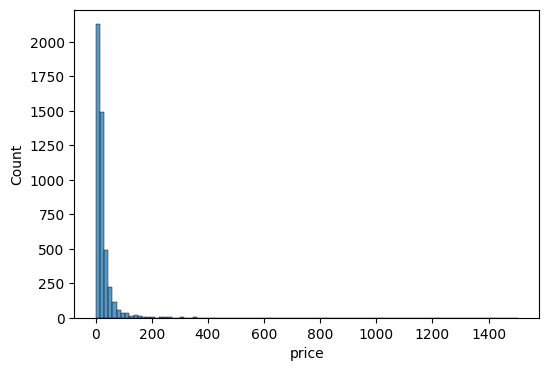

In [6]:
import matplotlib.pyplot as plt
import seaborn as  sns
y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df,bins=100)
plt.show()

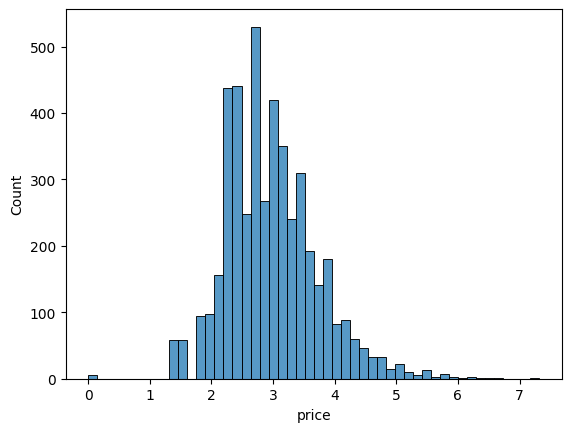

In [8]:
import numpy as np
y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [9]:
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)


,price
0,2.397895
1,3.970292
2,2.397895


In [11]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형: \n',mercari_df ['item_condition_id' ].value_counts())

Shipping 값 유형:
 shipping
0    2539
1    2119
Name: count, dtype: int64
item_condition_id 값 유형: 
 item_condition_id
1    2064
3    1338
2    1138
4     111
5       7
Name: count, dtype: int64


In [14]:
boolean_cond = mercari_df['item_description'] == 'No description yet'
mercari_df[boolean_cond]['item_description'].count()

np.int64(4658)

In [15]:
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null' , 'Other_Null' , 'Other_Null']

# 대, 중, 소 카테고리를 분리하여 새로운 칼럼 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수:', mercari_df['cat_jung'].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     2009
Beauty                     704
Kids                       546
Electronics                382
Men                        306
Home                       221
Other                      167
Vintage & Collectibles     145
Sports & Outdoors           78
Handmade                    78
Other_Null                  22
Name: count, dtype: int64
중분류 개수: 98
소분류 개수: 388


In [16]:
# 결측치(Null)를 'None' 또는 'Other_Null' 등으로 대체
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='None')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='No description yet')

# 모든 칼럼의 결측치 개수 확인
mercari_df.isnull().sum()


,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


In [17]:
print('brand_name 의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand_name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand_name 의 유형 건수 : 502
brand_name sample 5건 : 
 brand_name
None                 2008
Nike                  156
Victoria's Secret     152
PINK                  150
LuLaRoe                91
Name: count, dtype: int64


In [18]:
print('name 의 종류 개수 ：', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name 의 종류 개수 ： 4606
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


In [19]:
pd.set_option('max_colwidth', 200)
# item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())
mercari_df['item_description'][:2]


item_description 평균 문자열 크기: 18.0


,item_description
0,No description yet
1,No description yet


In [20]:
# name은 CountVectorizer, item_description은 TfidfVectorizer 사용
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vector shape:', X_name.shape)
print('item_description vector shape:', X_descp.shape)

name vector shape: (4658, 4922)
item_description vector shape: (4658, 1)


In [21]:
from sklearn.preprocessing import LabelBinarizer

# 나머지 피처들을 희소 행렬 원-핫 인코딩(LabelBinarizer) 변환
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])

lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# 카테고리 분리된 피처들을 인코딩
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [22]:
# 변환된 데이터 세트의 타입과 shape 확인
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape: {0}, X_item_cond_id shape: {1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape: {0}, X_cat_dae shape: {1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape: {0}, X_cat_so shape: {1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape: (4658, 502), X_item_cond_id shape: (4658, 5)
X_shipping shape: (4658, 1), X_cat_dae shape: (4658, 11)
X_cat_jung shape: (4658, 98), X_cat_so shape: (4658, 388)


In [23]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack을 이용해 희소 행렬들을 결합
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 결합 후 불필요한 메모리 해제를 위해 del과 gc 사용 가능 (실습 시 유의)
# del X_features_sparse
# gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (4658, 5928)


In [24]:
def rmsle(y , y_pred):
    # 언더플로 방지를 위해 log1p 사용
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test , preds):
    # 로그 변환된 값을 다시 원래 가격으로 변환 (expm1 사용)
    preds_expm = np.expm1(preds)
    y_test_expm = np.expm1(y_test)

    # RMSLE 계산
    rmsle_result = rmsle(y_test_expm, preds_expm)
    return rmsle_result

In [27]:
import gc
from scipy.sparse import hstack
def model_train_predict(model, matrix_list):
    # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
    X = hstack(matrix_list).tocsr()
    X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'],
    test_size=0.2, random_state=156)
    # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    del X, X_train, X_test, y_train
    gc.collect()
    return preds, y_test

In [31]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)
sparse_matrix_list = (X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))
sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.619656884498767
Item Description을 포함한 rmsle 값: 0.6193618101686929


In [32]:
from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list= sparse_matrix_list)
print('LightGBM rmsle:', evaluate_org_price(y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 523
[LightGBM] [Info] Number of data points in the train set: 3726, number of used features: 256
[LightGBM] [Info] Start training from score 2.961855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM rmsle: 0.7219205731489617


In [33]:
preds = lgbm_preds * 0.45 + linear_preds * 0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))


LightGBM과 Ridge를 ensemble한 최종 rmsle 값: 0.6175189411760594
